<a href="https://colab.research.google.com/github/SandroBolkvadze/Facial-Expression-Recognition-Kaggle-Competition/blob/main/facial-expression-recognition-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install dependencies

In [1]:
! pip install --upgrade kaggle wandb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 15.6 MB/s eta 0:00:00


# Imports

In [2]:
import pandas as pd
import numpy as np

import torch
import torchvision.transforms as transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD, Adam

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Use GPU
USE_GPU = True
device = 'cuda' if USE_GPU and torch.cuda.is_available() else 'cpu'
print('Device available:', device)

Device available: cuda


# Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Copy Access Token

In [4]:
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/kaggle/access_token ~/.kaggle/access_token
! chmod 600 ~/.kaggle/access_token

# Download Kaggle Competition Data

In [5]:
! kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:01<00:00, 250MB/s]



# Unzip Kaggle Competition Data

In [6]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


# Wandb Login

In [7]:
import wandb
! wandb login --relogin

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


# Read & Transform Dataset

In [8]:

# Simple function for transforming 'pixels' elements
def pixels_to_image(pixels_str):
  pixels = np.array(pixels_str.split(), dtype=np.uint8)
  pixels = pixels.reshape(48, 48)
  return pixels

In [9]:
df = pd.read_csv('./icml_face_data.csv')

# Rename columns
df.columns = ['emotion', 'Usage', 'pixels']

# Choose Training part
df = df[df['Usage'] == 'Training']

# Drop 'Usage' column
df = df.drop(columns=['Usage'])

# Transform 'pixels' elements to numpy array in advance
df['pixels'] = df['pixels'].apply(pixels_to_image)


In [10]:
X = df.drop(columns=['emotion'])
y = df['emotion']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (28709, 1)
y shape: (28709,)


# Split Dataset

In [11]:
train_size = .7
val_size   = .15
test_size  = .15

# Split full dataset into train and val/test sets
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y,
    test_size=(val_size+test_size)/(train_size+val_size+test_size),
    stratify=y,
)

# Split val/test dataset into 50/50 val and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test,
    test_size=test_size/(val_size+test_size),
    stratify=y_val_test,
)

# Split full dataset into 70/15/15 train/val/test sets
print(f'X_train shape {X_train.shape} and y_train shape {y_train.shape}')
print(f'X_val shape {X_val.shape} and y_val shape {y_val.shape}')
print(f'X_test shape {X_test.shape} and y_test shape {y_test.shape}')

X_train shape (20096, 1) and y_train shape (20096,)
X_val shape (4306, 1) and y_val shape (4306,)
X_test shape (4307, 1) and y_test shape (4307,)


In [12]:
# Check if label distributions are same in train/val/test sets
y_train_dist = y_train.value_counts() / y_train.value_counts().sum()
y_val_dist   = y_val.value_counts()   / y_val.value_counts().sum()
y_test_dist  = y_test.value_counts()  / y_test.value_counts().sum()

# Should have roughly equal numbers across rows of 'emotions'
y_dist = pd.DataFrame({
    'y_train': y_train_dist,
    'y_val'  : y_val_dist,
    'y_test' : y_test_dist,
})

print(y_dist)

          y_train     y_val    y_test
emotion                              
3        0.251294  0.251277  0.251451
6        0.172920  0.173014  0.172974
4        0.168242  0.168137  0.168331
2        0.142715  0.142592  0.142791
0        0.139182  0.139108  0.139076
5        0.110470  0.110543  0.110286
1        0.015177  0.015327  0.015092


# Transform Raw Pixels

In [13]:
# Calculate mean pixel over whole train dataset
mean_pixel = X_train['pixels'].apply(np.mean).mean() / 255.0

# Transform 2d numpy pixel array
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean_pixel,), std=(1.0,)),
])

# Custom Image Dataset

In [14]:
class ImageDataset(Dataset):
  def __init__(self, X, y, transform=None):
    self.X = X
    self.y = torch.tensor(y.values)
    self.transform = transform

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    image = self.X.iloc[index, 0]
    label = self.y[index]

    if self.transform:
      image = self.transform(image)

    return image, label

# Datasets & DataLoaders

In [15]:
train_dataset = ImageDataset(X_train, y_train, transform)
val_dataset   = ImageDataset(X_val, y_val, transform)
test_dataset  = ImageDataset(X_test, y_test, transform)

In [16]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

# Check Accuracy & Loss

In [29]:
def evaluate(loader, model, criterion=None):
  model.eval()

  total_loss, correct, total = 0, 0, 0

  with torch.no_grad():
    for t, (x, y) in enumerate(loader):
      x, y = x.to(device), y.to(device)

      scores = model(x)
      _, preds = scores.max(1)

      if criterion:
        total_loss += criterion(scores, y)

      correct += (preds == y).sum().item()
      total += y.shape[0]

  return correct / total, total_loss / len(loader)

# Train

In [30]:
def train(loader_train, loader_val, model, criterion, optimizer, epochs=100, print_every=1):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  for e in range(epochs):
    model.train()

    total_loss, correct, total = 0, 0, 0

    for t, (x, y) in enumerate(loader_train):
      x, y = x.to(device), y.to(device)

      # Calculate scores
      scores = model(x)

      # Calculate loss
      loss = criterion(scores, y)

      # Zero out grads
      optimizer.zero_grad()

      # Backpropagation
      loss.backward()

      # Update model parameters
      optimizer.step()

      # Maintain train stats
      _, preds    = scores.max(1)
      total_loss += loss.item()
      correct    += (preds == y).sum().item()
      total      += y.shape[0]

    # Train history
    history['train_loss'].append(total_loss / len(loader_train))
    history['train_acc'].append(correct / total)

    # Validation history
    val_acc, val_loss = evaluate(loader_val, model, criterion)
    history['val_loss'].append(val_loss.item())
    history['val_acc'].append(val_acc)

    wandb.log({
      'train_loss': history['train_loss'][-1],
      'train_acc':  history['train_acc'][-1],
      'val_loss':   history['val_loss'][-1],
      'val_acc':    history['val_acc'][-1],
      'epoch':      e,
    })

    if e % print_every == 0:
      print('[Epoch %d / %d]' % (e+1, epochs,))
      print('train_loss: %.4f; train_acc: %.4f; val_acc: %.4f' % (history['train_loss'][-1], history['train_acc'][-1], val_acc,))
      print()

  return history

# Two Layer FC

In [31]:
class TwoLayerFC(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()

    # Initialize Layers
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, output_size)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()

    # Initialize weights & biases
    nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
    nn.init.zeros_(self.fc1.bias)

    nn.init.xavier_normal_(self.fc2.weight)
    nn.init.zeros_(self.fc2.bias)


  def forward(self, x):
    # Flatten input
    x = self.flatten(x)

    # Apply Linear -> ReLU
    x = self.relu(self.fc1(x))

    # Apply Linear
    x = self.fc2(x)

    return x

# Check: Loss is reasonable for untrained model

In [32]:
# Create model, criterion, optimizer
model = TwoLayerFC(48*48, 64, 7).to(device)
criterion = nn.CrossEntropyLoss()

_, loss = evaluate(train_loader, model, criterion)
print('Loss: %.4f' % loss)

Loss: 2.0068


# Check: Model can overfit small data

In [33]:
small_data_size = 32

X_small_train = X_test[:small_data_size]
y_small_train = y_test[:small_data_size]

small_dataset = ImageDataset(X_small_train, y_small_train, transform)
small_loader  = DataLoader(small_dataset, batch_size=small_data_size, shuffle=True)

In [34]:
# Create model, criterion, optimizer
model = TwoLayerFC(48*48, 64, 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

# Train model
_ = train(small_loader, small_loader, model, criterion, optimizer, epochs=15)

Error: You must call wandb.init() before wandb.log()

# Train TwoLayerFC model

In [28]:
config={
    'learning_rate': 5e-2,
    'epochs': 100,
    'batch_size': batch_size,
    'optimizer': 'sgd',
    'loss_function': 'CrossEntropyLoss',
    'architecture': 'TwoLayerFC',
}

run = wandb.init(
    project='Facial_Expression_Recognition_01',
    name="TwoLayerFC",
    config=config
)

model = TwoLayerFC(48*48, 64, 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=config['learning_rate'])

wandb.watch(model, log='all')

train_loss_history, train_acc_history, val_loss_history, val_acc_history = train(train_loader, val_loader, model, criterion, optimizer, epochs=config['epochs'], print_every=1)

wandb.finish()

[Epoch 1 / 100]
train_loss: 1.7225; train_acc: 0.3125; val_acc: 0.3639

[Epoch 2 / 100]
train_loss: 1.6119; train_acc: 0.3722; val_acc: 0.3748

[Epoch 3 / 100]
train_loss: 1.5666; train_acc: 0.3960; val_acc: 0.3830

[Epoch 4 / 100]
train_loss: 1.5341; train_acc: 0.4124; val_acc: 0.3871

[Epoch 5 / 100]
train_loss: 1.5067; train_acc: 0.4234; val_acc: 0.3902

[Epoch 6 / 100]
train_loss: 1.4812; train_acc: 0.4348; val_acc: 0.3934

[Epoch 7 / 100]
train_loss: 1.4574; train_acc: 0.4463; val_acc: 0.3941

[Epoch 8 / 100]
train_loss: 1.4360; train_acc: 0.4526; val_acc: 0.3869

[Epoch 9 / 100]
train_loss: 1.4159; train_acc: 0.4621; val_acc: 0.4001

[Epoch 10 / 100]
train_loss: 1.3945; train_acc: 0.4722; val_acc: 0.4029

[Epoch 11 / 100]
train_loss: 1.3759; train_acc: 0.4790; val_acc: 0.3974

[Epoch 12 / 100]
train_loss: 1.3558; train_acc: 0.4906; val_acc: 0.3980

[Epoch 13 / 100]
train_loss: 1.3357; train_acc: 0.4972; val_acc: 0.4018

[Epoch 14 / 100]
train_loss: 1.3163; train_acc: 0.5105; val_

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇███
train_acc,▁▂▂▂▂▃▃▃▃▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,█▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇█▇▆▄▇█▅▆▆▇▆▃▄▃▄▄▆▆▄▁▃▆▅▂▃▄▂▄▆▃▆▃▆▅
val_loss,▁▁▁▁▁▁▁▂▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▅▆▆▆▇█
epoch,99
train_acc,0.89092
train_loss,0.35804
val_acc,0.39201
val_loss,3.05557


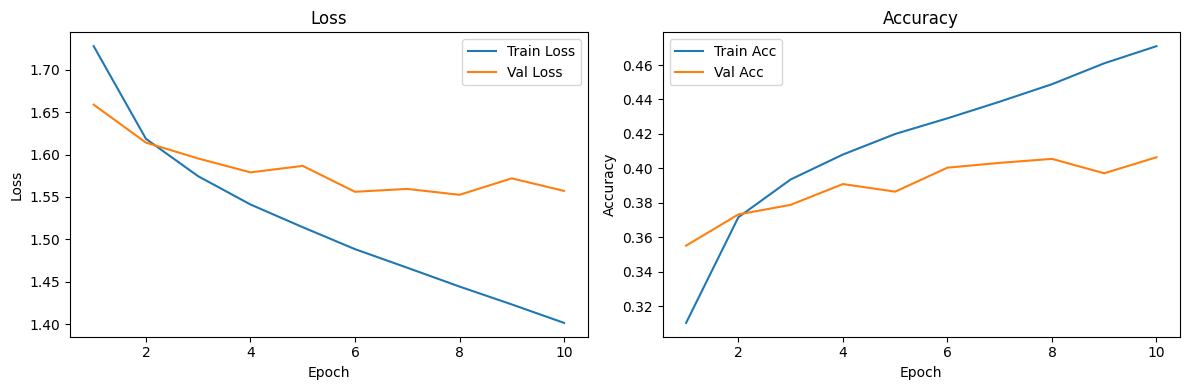

In [27]:
def plot_history(train_loss, train_acc, val_loss, val_acc):
    epochs = range(1, len(train_loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, train_loss, label='Train Loss')
    ax1.plot(epochs, val_loss, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy
    ax2.plot(epochs, train_acc, label='Train Acc')
    ax2.plot(epochs, val_acc, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(train_loss_history, train_acc_history, val_loss_history, val_acc_history)